# 9. TEM Profiler: Forward Models

Compare 1000 synthetic 1D earth models with the 100th Tunoe USF sounding in filename order. This ranks a random model ensemble; no inversion is performed.

The 3 x 3 m square transmitter is represented by an equal-area circular loop with a 13 m receiver offset. Two cascaded first-order low-pass stages at 250 and 800 kHz are used, with no high-pass filter.

The shared 75-point step-time grid is configurable and is not a guarantee of convergence for every earth model. An external USF directory is required; edit `USF_DIR` when running elsewhere.

In [34]:
from pathlib import Path
import sys
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

ROOT = next(
    folder for folder in [Path.cwd(), *Path.cwd().parents]
    if (folder / 'pytem').is_dir()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pytem import read_usf, setup_shared_gate_matrices, cascade_filter, fwd_circle_offset

In [35]:
USF_DIR = Path(
    r'C:\Users\pamcl\OneDrive - Danmarks Tekniske Universitet\Dokumenter\Projects_Sorted\Current\Denmark\Tunoe\raw\Tunoe\Data\USF_Files_Tunoe'
 )
tem = read_usf(USF_DIR)
MOMENTS = ['LM', 'HM']
CURRENTS = {'LM': 1.0, 'HM': 10.0}
LOW_PASS_HZ = (250_000.0, 800_000.0)
N_STEP = 75 # Number of steps for the gate matrices for waveform, large values increase accuracy but also computational cost

TRANSFORM = 'euler' # Specify the type of transform to use

systems = {moment: tem.to_pytem(moment, peak_current=CURRENTS[moment])
           for moment in MOMENTS}

tx_side = float(systems['HM']['tx_size'])
tx_radius = np.sqrt(3.0 ** 2 / np.pi) # Calculate the equivalent radius of the transmitter coil assuming a circular shape
rx_offset = 13.0 # Set the radial offset of the receiver coil
receiver_filter = cascade_filter(*LOW_PASS_HZ)
t_step, gate_matrices = setup_shared_gate_matrices(systems, n_step=N_STEP)

c:\WPy64-31180\python-3.11.8.amd64\Lib\site-packages\numpy\core\_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
c:\WPy64-31180\python-3.11.8.amd64\Lib\site-packages\numpy\lib\nanfunctions.py:1741: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe', where=where)


## Generate the Earth Models

A fixed seed produces reproducible resistivity profiles from 5 to 500 Ohm.m. Each model has four independently sampled finite-layer thicknesses, uniform from 2 to 30 m, followed by a half-space. Five random log-resistivity control values are interpolated onto each model's layer tops.

In [36]:
import numpy as np
import matplotlib.pyplot as plt

N_MODELS = 10000
N_LAYERS = 4  # Change this one value to increase the number of layers
# Target means for the original three-layer example. Interpolate them when N_LAYERS changes.
rho_anchor = np.array([50.2, 24.7, 2.5])
thickness_anchor = np.array([30.1, 27.7])
layer_axis = np.linspace(0.0, 1.0, N_LAYERS)
boundary_axis = np.linspace(0.0, 1.0, N_LAYERS - 1)
RHO_MEANS = 10.0 ** np.interp(
    layer_axis, np.linspace(0.0, 1.0, rho_anchor.size), np.log10(rho_anchor)
)
THICKNESS_MEANS = np.interp(
    boundary_axis, np.linspace(0.0, 1.0, thickness_anchor.size), thickness_anchor
)
SEED = 42
RHO_RANGE = (1.0, 500.0)
THICKNESS_RANGE = (2.0, 40.0)

rng = np.random.default_rng(SEED)

# Sample thicknesses around the means
# Using the mean as center, with std based on range
thickness_std = (THICKNESS_RANGE[1] - THICKNESS_RANGE[0]) / 6  # ~95% within range

thicknesses = np.zeros((N_MODELS, N_LAYERS - 1))
for i in range(N_LAYERS - 1):
    thicknesses[:, i] = rng.normal(
        loc=THICKNESS_MEANS[i],
        scale=thickness_std,
        size=N_MODELS
    )
    # Clip to valid range
    thicknesses[:, i] = np.clip(thicknesses[:, i], *THICKNESS_RANGE)

layer_tops = np.column_stack((np.zeros(N_MODELS), np.cumsum(thicknesses, axis=1)))

# Sample resistivities around the means (in log space)
# Convert means to log space
log_rho_means = np.log10(RHO_MEANS)
log_rho_std = (np.log10(RHO_RANGE[1]) - np.log10(RHO_RANGE[0])) / 6

log_resistivities = np.zeros((N_MODELS, N_LAYERS))
for i in range(N_LAYERS):
    log_resistivities[:, i] = rng.normal(
        loc=log_rho_means[i],
        scale=log_rho_std,
        size=N_MODELS
    )
    # Clip to valid log range
    log_resistivities[:, i] = np.clip(
        log_resistivities[:, i],
        np.log10(RHO_RANGE[0]),
        np.log10(RHO_RANGE[1])
    )

resistivities = 10.0 ** log_resistivities


model_ids = np.arange(1, N_MODELS + 1)

# Verify means
print("Mean resistivities:", resistivities.mean(axis=0))
print("Target resistivities:", RHO_MEANS)
print("Mean thicknesses:", thicknesses.mean(axis=0))
print("Target thicknesses:", THICKNESS_MEANS)

Mean resistivities: [82.31848618 51.14672718 19.75658185  4.41087125]
Target resistivities: [50.2        31.28714065 11.51095365  2.5       ]
Mean thicknesses: [29.87162932 28.92277823 27.72156584]
Target thicknesses: [30.1 28.9 27.7]


## Forward Models and Data Misfit

Models are evaluated sequentially by direct calls to `fwd_circle_offset`; timing includes first-call numerical compilation. An error stops execution.

Each filtered step response is mapped to LM and HM gates. The matrices include the transmitter waveform and current amplitude, so current is not multiplied in again. Responses are signed voltage per receiver area in V/m², equivalent to dB/dt in T/s. Observations are converted from the USF current-normalized units using the same LM/HM currents as the predictions.

`rms_matrix` has one row per model and columns LM, HM and Combined. Each entry is sqrt(mean(((prediction - observation) / sigma)**2)), with sigma = |observation| times the measured fractional uncertainty, floored at 3%. Combined RMS pools all valid gates, rather than averaging the two moment RMS values. Invalid observations or uncertainties are excluded for every model; nonfinite predictions cannot win the combined ranking.

The 100th sounding is index 99 in filename order. Lower noise-weighted RMS is better; a value near 1 means residuals comparable to the assumed uncertainties. This is not an unweighted RMS in voltage units. The existing USF reader uses observation magnitudes; its absolute current/area calibration interpretation has not been independently verified.

In [37]:
responses = {
    moment: np.full((N_MODELS, systems[moment]['times'].size), np.nan)
    for moment in MOMENTS
}
successful = np.zeros(N_MODELS, dtype=bool)

started = time.perf_counter()

for model_index, rho in enumerate(resistivities):
    if model_index % (0.05 * N_MODELS) == 0:
            print(f'Starting model {model_index} of {N_MODELS} models')

    step_response = -fwd_circle_offset(
        thicknesses[model_index], rho, tx_radius, rx_offset, t_step,
        current=1.0, signal=-1,
        use_numba=True, use_cuda=False,
        transform=TRANSFORM, system_filter=receiver_filter
    )

    for moment in MOMENTS:
        responses[moment][model_index] = gate_matrices[moment] @ step_response

    successful[model_index] = True

print(f'{N_MODELS} models in {time.perf_counter() - started:.2f} s')

Starting model 0 of 10000 models
Starting model 500 of 10000 models
Starting model 1000 of 10000 models
Starting model 1500 of 10000 models
Starting model 2000 of 10000 models
Starting model 2500 of 10000 models
Starting model 3000 of 10000 models
Starting model 3500 of 10000 models
Starting model 4000 of 10000 models
Starting model 4500 of 10000 models
Starting model 5000 of 10000 models
Starting model 5500 of 10000 models
Starting model 6000 of 10000 models
Starting model 6500 of 10000 models
Starting model 7000 of 10000 models
Starting model 7500 of 10000 models
Starting model 8000 of 10000 models
Starting model 8500 of 10000 models
Starting model 9000 of 10000 models
Starting model 9500 of 10000 models
10000 models in 414.47 s


In [38]:
STATION_INDEX = 99
selected_usf = sorted(USF_DIR.glob('*.usf'))[STATION_INDEX]
observed_systems = {
    moment: tem.to_pytem(moment, station=STATION_INDEX, peak_current=CURRENTS[moment])
    for moment in MOMENTS
}
rms_columns = [*MOMENTS, 'Combined']
rms_matrix = np.full((N_MODELS, len(rms_columns)), np.inf)
normalized_residuals = []
valid_gates = {}

for moment_index, moment in enumerate(MOMENTS):
    observed = observed_systems[moment]['obs_data']
    fractional_noise = tem.dbdt_std(moment)[STATION_INDEX]
    valid = (np.isfinite(observed) & (observed > 0)
             & np.isfinite(fractional_noise) & (fractional_noise >= 0))
    valid_gates[moment] = valid
    if not np.any(valid):
        raise ValueError(f'No valid {moment} gates in {selected_usf.name}')
    sigma = observed[valid] * np.maximum(fractional_noise[valid], 0.03)
    residuals = (responses[moment][:, valid] - observed[valid]) / sigma
    normalized_residuals.append(residuals)
    rms_matrix[:, moment_index] = np.sqrt(np.mean(residuals ** 2, axis=1))
    print(f'{moment}: {valid.sum()}/{valid.size} gates used')

residual_matrix = np.concatenate(normalized_residuals, axis=1)
rms_matrix[:, -1] = np.sqrt(np.mean(residual_matrix ** 2, axis=1))
rms_matrix[~np.isfinite(rms_matrix)] = np.inf
rms_matrix[~successful] = np.inf
ranked_indices = np.argsort(rms_matrix[:, -1])
ranked_indices = ranked_indices[np.isfinite(rms_matrix[ranked_indices, -1])]
if ranked_indices.size == 0:
    raise ValueError('No models have finite RMS values')
best_indices = ranked_indices[:10]
best_model_index = best_indices[0]

print(f'100th USF: {selected_usf.name}')
print('Model ID        LM RMS        HM RMS  Combined RMS')
for model_index in best_indices:
    print(f'{model_ids[model_index]:8d}'
          f'{rms_matrix[model_index, 0]:14.3f}'
          f'{rms_matrix[model_index, 1]:14.3f}'
          f'{rms_matrix[model_index, 2]:14.3f}')

LM: 8/8 gates used
HM: 21/21 gates used
100th USF: L004_S014_2026_0909_092618.usf
Model ID        LM RMS        HM RMS  Combined RMS
    6337         1.781         1.042         1.289
    4710         3.009         2.539         2.677
    6453         2.550         2.781         2.720
    5289         3.390         2.515         2.784
    5447         4.264         2.586         3.140
    9828         3.569         3.388         3.439
    7388         3.143         3.595         3.476
    5848         4.557         2.971         3.482
    5074         4.812         2.848         3.502
    2058         3.009         3.763         3.571


## Markov-Chain Monte Carlo (MCMC): fitting a TEM sounding

The notebook is a short, from-scratch MCMC tutorial applied to this station's sounding, adapted from ["MCMC: A (very) Beginner's Guide"](https://prappleizer.github.io/Tutorials/MCMC/MCMC_Tutorial.html).

**What MCMC is.** MCMC is not an optimiser: it is a *sampler*. Rather than returning a single "best" earth model, it draws many samples from the posterior probability distribution of the model parameters given the data, using Bayes' theorem

$$P(\theta \mid D) = \frac{P(D \mid \theta)\, P(\theta)}{P(D)}$$

- $P(D \mid \theta)$, the **likelihood**, measures how well a candidate model $\theta$ reproduces the observed gates.
- $P(\theta)$, the **prior**, encodes what we already consider a plausible earth model before looking at the data.
- $P(\theta \mid D)$, the **posterior**, is what the chain samples from.

**The four ingredients.** Following the tutorial's structure, we define:

1. `model(theta)` - the forward TEM response for a set of parameters.
2. `lnlike(theta)` - the log-likelihood, `-0.5 * chi_squared`, where chi_squared sums squared residuals divided by the gate noise (with a 3% floor), the same convention used in the ensemble ranking above.
3. `lnprior(theta)` - flat priors: log10-resistivity within `RHO_RANGE`, thickness within `THICKNESS_RANGE`, layer count fixed at `N_LAYERS`. Returns `0.0` inside bounds, `-inf` outside.
4. `lnprob(theta)` - `lnprior(theta) + lnlike(theta)`, or `-inf` if the prior rejects `theta`.

**Parameters.** theta = (log10 rho_1, ..., log10 rho_N_LAYERS, thickness_1, ..., thickness_(N_LAYERS - 1)); unlike the ensemble above, each layer resistivity is sampled independently rather than interpolated from a handful of control points.

**Running the chain.** Several independent Metropolis-Hastings chains are started near the best ensemble model found above. Each chain proposes a small Gaussian step away from its current position and accepts or rejects it with the Metropolis-Hastings rule; a short burn-in phase is discarded before collecting the production samples used below. As in the tutorial, this is a sampler, not a fitter - don't expect exact convergence to a single answer, and use the trace plots to judge whether the chains have settled down.

In [39]:
LOG_RHO_STEP = 0.03      # Metropolis-Hastings proposal step size, log10(Ohm.m)
THICKNESS_STEP = 0.75    # Metropolis-Hastings proposal step size, m
N_LAYERS = 4

# Stack the valid LM/HM gates (and their noise) once, matching the RMS section above.
obs_list, sig_list, gate_list, moment_slices = [], [], [], {}
cursor = 0
for moment in MOMENTS:
    valid = valid_gates[moment]
    observed = observed_systems[moment]['obs_data'][valid]
    sigma = observed * np.maximum(tem.dbdt_std(moment)[STATION_INDEX, valid], 0.03)
    obs_list.append(observed)
    sig_list.append(sigma)
    gate_list.append(gate_matrices[moment][valid])
    moment_slices[moment] = slice(cursor, cursor + observed.size)
    cursor += observed.size

obs = np.concatenate(obs_list)     # all valid observed gates, LM then HM, stacked into one vector
sig = np.concatenate(sig_list)     # matching per-gate noise (standard deviation) for the chi-squared below
G = np.vstack(gate_list)           # matching gate matrices, so G @ step_response lines up with obs/sig

print(f'Fitting station {STATION_INDEX} ({selected_usf.name}) with {obs.size} valid LM/HM gates')

LOG_RHO_BOUNDS = np.log10(RHO_RANGE)
# theta = [log10(rho_1..rho_N_LAYERS), thickness_1..thickness_(N_LAYERS-1)]; the half-space has no thickness.
N_PARAMS = N_LAYERS + (N_LAYERS - 1)


def model(theta):
    """Unpack theta into layer resistivities/thicknesses and return the predicted gate values."""
    log_rho, thickness = theta[:N_LAYERS], theta[N_LAYERS:]
    step_response = -fwd_circle_offset(
        thickness, 10.0 ** log_rho, tx_radius, rx_offset, t_step,
        current=1.0, signal=-1, use_numba=True, use_cuda=False,
        transform=TRANSFORM, system_filter=receiver_filter,
    )
    return G @ step_response  # map the shared step response onto this station's LM/HM gate times


def lnlike(theta):
    """Gaussian log-likelihood: -0.5 * chi_squared, chi_squared = sum(((prediction - obs) / sig) ** 2)."""
    try:
        prediction = model(theta)
    except Exception:
        return -np.inf  # forward model failed (e.g. degenerate layer) -> reject this theta outright
    if not np.all(np.isfinite(prediction)):
        return -np.inf
    return -0.5 * np.sum(((prediction - obs) / sig) ** 2)


def lnprior(theta):
    """Flat (uniform) prior: 0.0 log-probability inside the ensemble's bounds, -inf outside."""
    log_rho, thickness = theta[:N_LAYERS], theta[N_LAYERS:]
    if (np.all((log_rho >= LOG_RHO_BOUNDS[0]) & (log_rho <= LOG_RHO_BOUNDS[1]))
            and np.all((thickness >= THICKNESS_RANGE[0]) & (thickness <= THICKNESS_RANGE[1]))):
        return 0.0
    return -np.inf


def lnprob(theta):
    """Un-normalised log-posterior: log(prior) + log(likelihood), the target the sampler climbs/explores."""
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf  # outside the prior bounds -> skip the (expensive) forward model entirely
    return lp + lnlike(theta)

Fitting station 99 (L004_S014_2026_0909_092618.usf) with 29 valid LM/HM gates


In [ ]:
import concurrent.futures as _cf

N_CHAINS = 6
N_BURN = 300
N_STEPS = 50000 
MCMC_SEED = 43

# Per-parameter Gaussian proposal width: too large -> most proposals rejected (low acceptance),
# too small -> the chain crawls and needs far more steps to explore the posterior.
PROPOSAL_STEP = np.r_[np.full(N_LAYERS, LOG_RHO_STEP),
                     np.full(N_LAYERS - 1, THICKNESS_STEP)]
theta0 = np.r_[np.log10(resistivities[best_model_index]), thicknesses[best_model_index]]
assert theta0.size == N_PARAMS

def run_chain(theta, n_steps, rng):
    """Metropolis-Hastings random walk: propose a nearby theta, accept/reject, repeat."""
    lp = lnprob(theta)
    chain = np.empty((n_steps, theta.size))
    lnprob_chain = np.empty(n_steps)
    n_accept = 0
    for step in range(n_steps):
        proposal = theta + PROPOSAL_STEP * rng.standard_normal(theta.size)
        lp_proposal = lnprob(proposal)
        # Metropolis rule: always accept an uphill step; accept a downhill step with
        # probability exp(lp_proposal - lp), so the chain still explores lower-probability regions.
        if np.isfinite(lp_proposal) and np.log(rng.uniform()) < lp_proposal - lp:
            theta, lp = proposal, lp_proposal
            n_accept += 1
        chain[step], lnprob_chain[step] = theta, lp
    return chain, lnprob_chain, n_accept / n_steps


def main(theta_start, n_burn, n_steps, rng):
    """Discard an initial n_burn steps (letting the chain forget its start), then keep n_steps."""
    burn_chain, _, _ = run_chain(theta_start, n_burn, rng)
    return run_chain(burn_chain[-1], n_steps, rng)


def _fmt_time(seconds):
    if seconds < 60:
        return f'{seconds:.0f} s'
    if seconds < 3600:
        return f'{seconds / 60:.1f} min'
    return f'{seconds / 3600:.1f} h'


# Time a handful of lnprob calls to estimate the full run before committing to it.
_N_CALIB = 50
_calib_start = time.perf_counter()
for _ in range(_N_CALIB):
    lnprob(theta0)
_s_per_step = (time.perf_counter() - _calib_start) / _N_CALIB
_total_steps = N_CHAINS * (N_BURN + N_STEPS)
print(f'Calibration: {_s_per_step * 1000:.1f} ms/step -> '
      f'estimated total runtime {_fmt_time(_s_per_step * _total_steps)} '
      f'for {N_CHAINS} chains x {N_BURN + N_STEPS} steps')

rng_master = np.random.default_rng(MCMC_SEED)
# Independent chains start at randomly jittered points near theta0, so the spread between
# them (checked via R-hat below) is a diagnostic for whether they all found the same posterior.
# Pre-generate starts/seeds from the master RNG (single-threaded) so results stay reproducible
# regardless of which worker finishes first.
chain_starts = [theta0 + PROPOSAL_STEP * rng_master.standard_normal(N_PARAMS)
                for _ in range(N_CHAINS)]
chain_seeds = [int(seed) for seed in rng_master.integers(1 << 32, size=N_CHAINS)]

def _run_one_chain(start, seed):
    return main(start, N_BURN, N_STEPS, np.random.default_rng(seed))

# Chains are independent, so run them concurrently: fwd_circle_offset(use_numba=True) releases
# the GIL while it runs (same reason invert_stations gets real speedup from threads), so this
# gives close to an N_CHAINS-fold speedup on a multi-core machine instead of running one at a time.
chains = [None] * N_CHAINS
lnprob_chains = [None] * N_CHAINS
acceptance = [None] * N_CHAINS
started = time.perf_counter()
n_done = 0
with _cf.ThreadPoolExecutor(max_workers=N_CHAINS) as pool:
    futures = {pool.submit(_run_one_chain, chain_starts[i], chain_seeds[i]): i
               for i in range(N_CHAINS)}
    for future in _cf.as_completed(futures):
        chain_index = futures[future]
        chain, lnprob_chain, acc = future.result()
        chains[chain_index] = chain
        lnprob_chains[chain_index] = lnprob_chain
        acceptance[chain_index] = acc

        n_done += 1
        elapsed = time.perf_counter() - started
        remaining = elapsed / n_done * (N_CHAINS - n_done)
        print(f'Chain {chain_index} done ({n_done}/{N_CHAINS}) in {_fmt_time(elapsed)} '
              f'(acceptance {acc:.2f}); ETA {_fmt_time(remaining)}')

chains = np.array(chains)               # (n_chains, n_steps, n_params), post burn-in
lnprob_chains = np.array(lnprob_chains)  # (n_chains, n_steps)

print(f'{N_CHAINS} chains x {N_STEPS} production steps '
      f'({N_BURN} burn-in each, discarded) in {_fmt_time(time.perf_counter() - started)}')
print('Acceptance rate per chain:', np.round(acceptance, 2),
      '(aim for roughly 0.2-0.5)')

Calibration: 92.0 ms/step -> estimated total runtime 7.7 h for 6 chains x 50300 steps
Chain 0 done (1/6) in 3.1 h (acceptance 0.01); ETA 15.7 h
Chain 1 done (2/6) in 3.1 h (acceptance 0.01); ETA 6.3 h
Chain 2 done (3/6) in 3.2 h (acceptance 0.01); ETA 3.2 h
Chain 5 done (4/6) in 3.2 h (acceptance 0.01); ETA 1.6 h
Chain 4 done (5/6) in 3.2 h (acceptance 0.01); ETA 37.9 min
Chain 3 done (6/6) in 3.2 h (acceptance 0.01); ETA 0 s
6 chains x 50000 production steps (300 burn-in each, discarded) in 3.2 h
Acceptance rate per chain: [0.01 0.01 0.01 0.01 0.01 0.01] (aim for roughly 0.2-0.5)


In [48]:
def gelman_rubin(x):
    """Gelman-Rubin R-hat per parameter: sqrt(pooled variance / within-chain variance); ~1 means the chains agree."""
    n = x.shape[1]                                     # steps per chain
    within = x.var(axis=1, ddof=1).mean(axis=0)        # average spread inside each chain
    between = n * x.mean(axis=1).var(axis=0, ddof=1)   # spread of the chain means from each other
    return np.sqrt(((n - 1) / n * within + between / n) / within)

rhat = gelman_rubin(chains)
param_names = ([f'log10(rho_{i + 1})' for i in range(N_LAYERS)]
              + [f'thickness_{i + 1} [m]' for i in range(N_LAYERS - 1)])
print('R-hat per parameter (aim for < 1.1):')
for name, value in zip(param_names, rhat):
    print(f'  {name:>18s}: {value:.3f}')

# Pool every chain's post-burn-in samples into one posterior sample set (order no longer matters).
flat_samples = chains.reshape(-1, N_PARAMS)
flat_lnprob = lnprob_chains.reshape(-1)
theta_max = flat_samples[np.argmax(flat_lnprob)]  # single highest-lnprob sample seen by any chain
print(f'\nHighest-likelihood theta: rho = {np.round(10 ** theta_max[:N_LAYERS], 1)} Ohm.m, '
      f'thickness = {np.round(theta_max[N_LAYERS:], 1)} m')

R-hat per parameter (aim for < 1.1):
        log10(rho_1): 1.244
        log10(rho_2): 1.179
        log10(rho_3): 1.042
        log10(rho_4): 1.002
     thickness_1 [m]: 1.280
     thickness_2 [m]: 1.319
     thickness_3 [m]: 1.042

Highest-likelihood theta: rho = [52.9 35.9  3.5  1.9] Ohm.m, thickness = [18.  34.8 18.7] m


> **What is R-hat?** R-hat (the Gelman-Rubin statistic) compares the variance *between* chains to the variance *within* each chain, for every parameter separately. If all chains have converged to the same posterior, they should look statistically indistinguishable from one another, so the between-chain and within-chain variances agree and R-hat approaches 1.
>
> - **R-hat close to 1 (say, < 1.1)**: the chains agree with each other; they are likely sampling the same posterior distribution, and the last N_STEPS production samples are reasonably trustworthy.
> - **R-hat well above 1 (as seen above, e.g. > 1.4 for some parameters)**: the chains have *not* converged to the same place. Some chains may still be drifting, stuck near their (randomised) starting point, or exploring a different region of parameter space than the others. Averaging over all chains in this state gives a misleading posterior.
>
> **Why this can happen here.** With only `N_LAYERS = 3` (5 free parameters) but noisy TEM data, the likelihood surface can have shallow, elongated, or multi-modal regions (e.g. resistivity-thickness trade-offs for a hidden layer). A short chain, a proposal step size that's poorly matched to the local curvature, or an unlucky starting point can leave a chain trapped away from the bulk of the posterior for the whole run.
>
> **What to do about it.** Check the trace plot below first: R-hat > 1.1 usually shows up there as one or more chains sitting at a visibly different level than the rest, rather than mixing randomly around a common value. If that's what you see, try increasing `N_BURN` and/or `N_STEPS`, adjusting `LOG_RHO_STEP`/`THICKNESS_STEP` (too large -> low acceptance and slow mixing; too small -> slow exploration), or starting the chains closer together. Treat any posterior summary computed below as provisional until R-hat is close to 1 for every parameter.


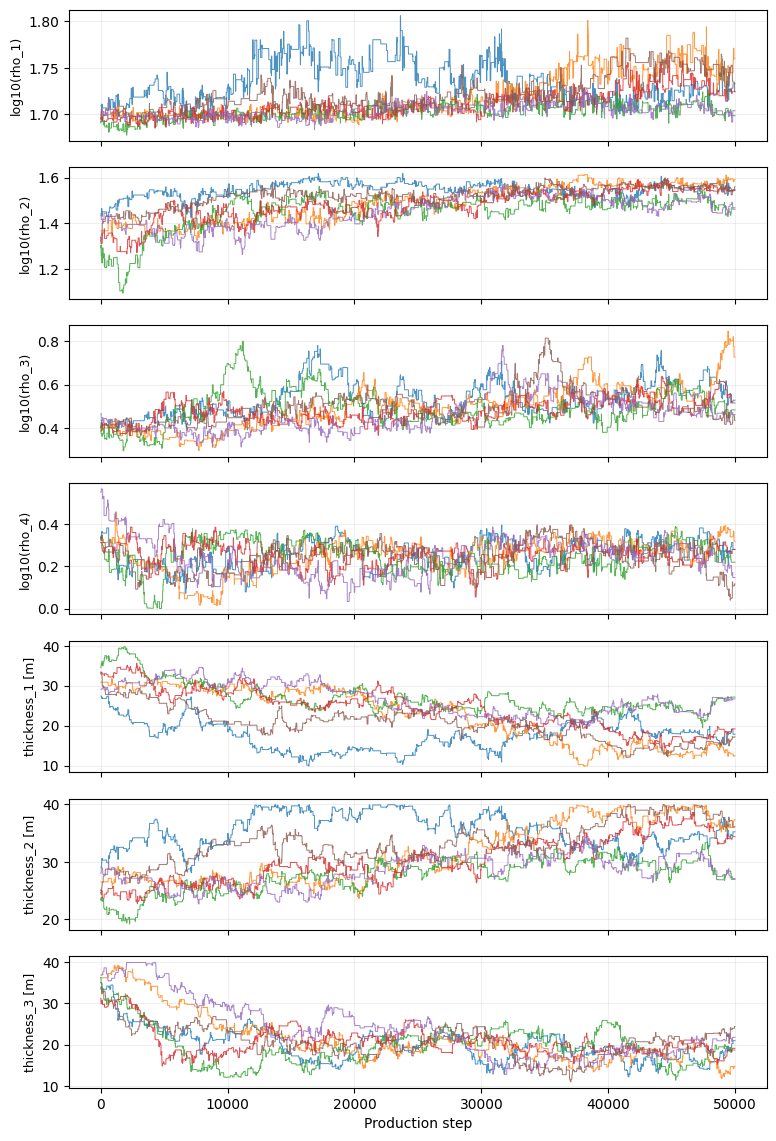

In [ ]:
trace_samples = chains.copy()
trace_samples[:, :, :N_LAYERS] = 10.0 ** trace_samples[:, :, :N_LAYERS]
trace_names = ([f'Layer {i + 1} Resistivity [Ohm.m]' for i in range(N_LAYERS)]
               + [f'Layer {i + 1} Thickness [m]' for i in range(N_LAYERS - 1)])

fig, axes = plt.subplots(N_PARAMS, 1, figsize=(9, 2 * N_PARAMS), sharex=True,
                         layout='constrained')
axes = np.atleast_1d(axes)
for param_index, (axis, name) in enumerate(zip(axes, trace_names)):
    for chain_index in range(N_CHAINS):
        axis.plot(trace_samples[chain_index, :, param_index], lw=0.7, alpha=0.8)
    axis.set_ylabel(name, fontsize=9)
    axis.grid(True, alpha=0.2)

rho_limits = trace_samples[:, :, :N_LAYERS]
rho_low = max(1.0, rho_limits.min() * 0.95)
rho_high = rho_limits.max() * 1.05
for axis in axes[:N_LAYERS]:
    axis.set_yscale('log')
    axis.set_ylim(rho_low, rho_high)
    axis.set_yticks([1, 10, 100, 1000])

if N_LAYERS > 1:
    thickness_limits = trace_samples[:, :, N_LAYERS:]
    thickness_low = thickness_limits.min() * 0.95
    thickness_high = thickness_limits.max() * 1.05
    for axis in axes[N_LAYERS:]:
        axis.set_ylim(thickness_low, thickness_high)

axes[-1].set_xlabel('Production step')
plt.show()

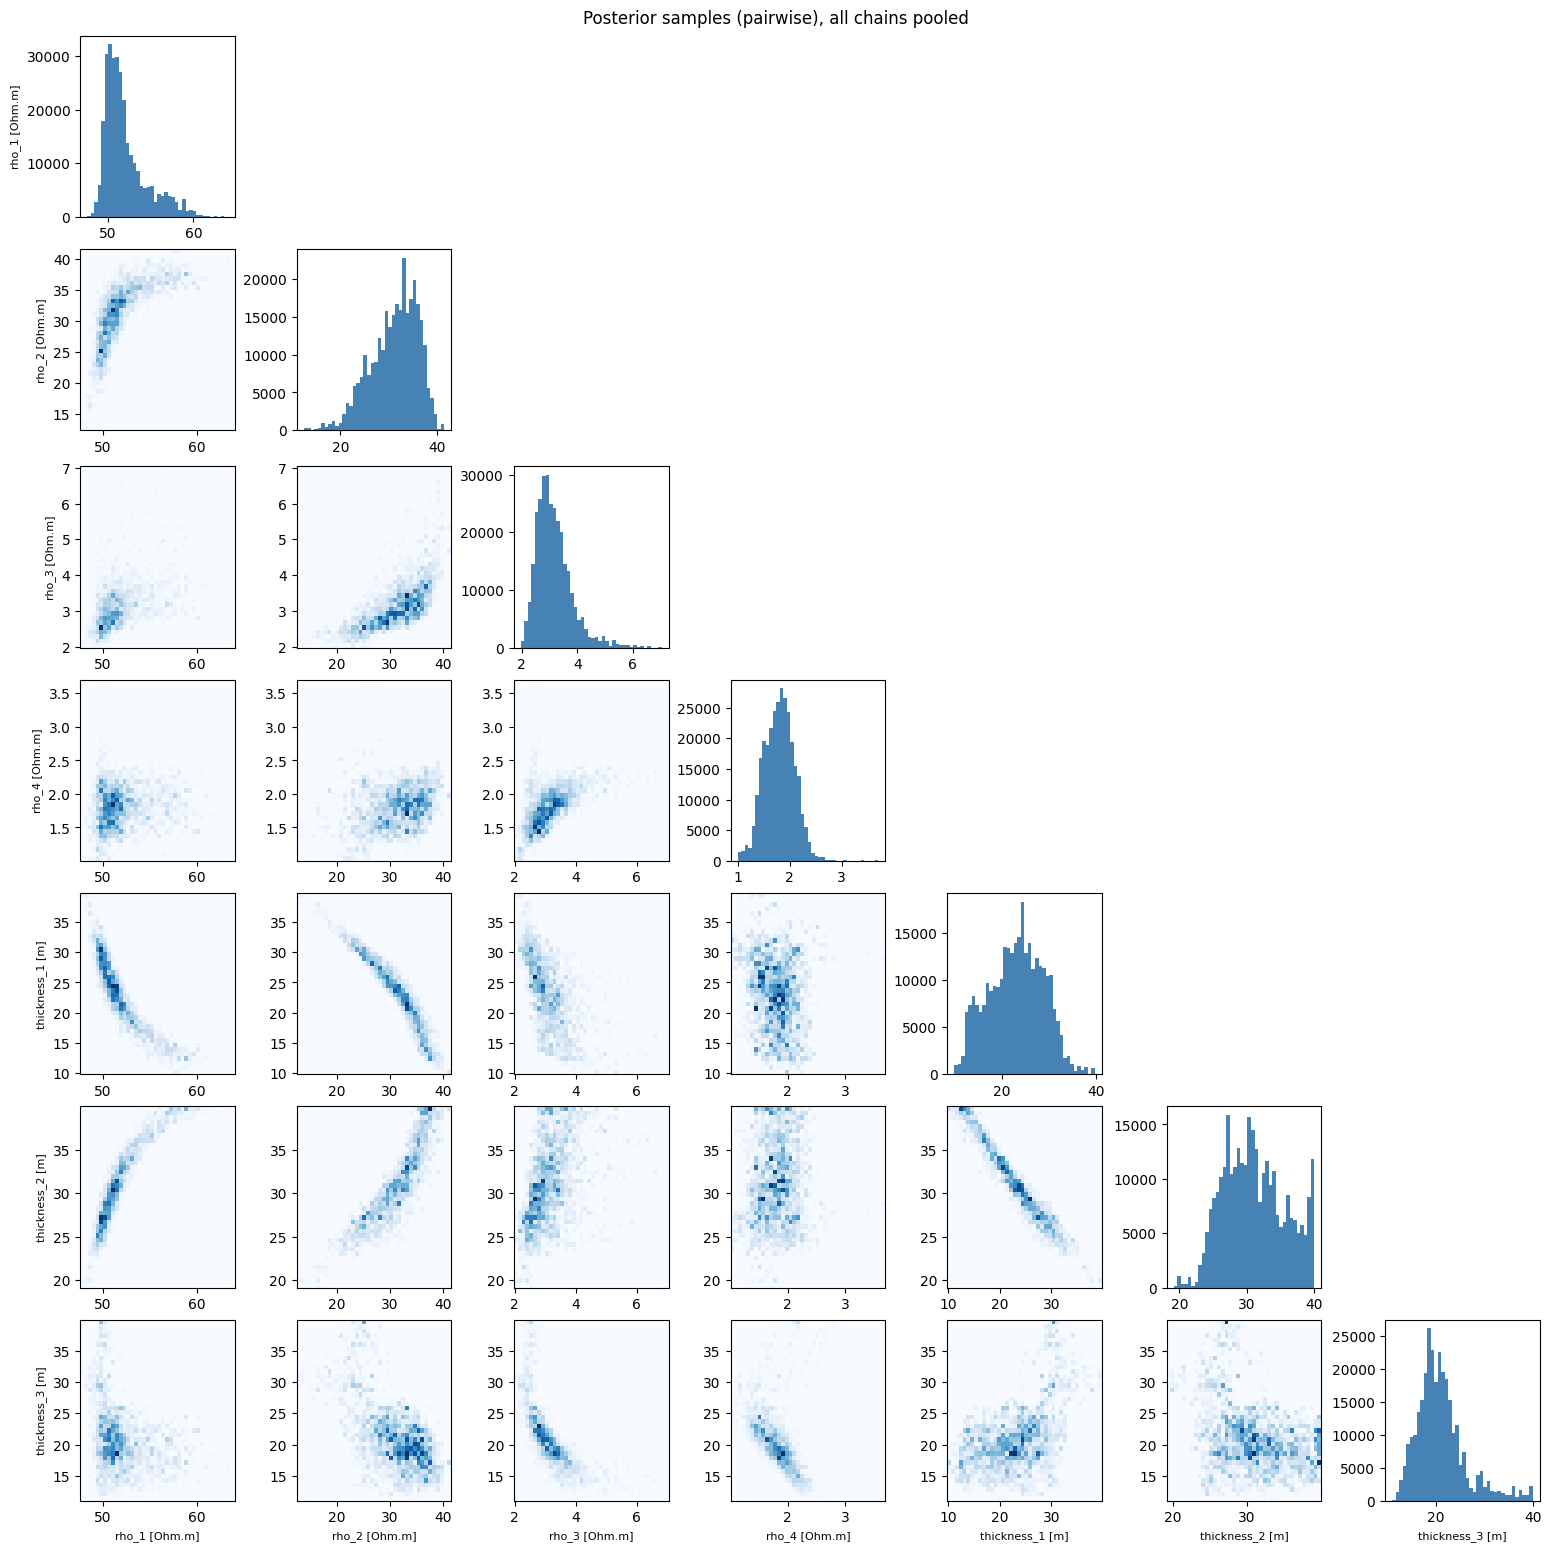

In [52]:
display_samples = flat_samples.copy()
display_samples[:, :N_LAYERS] = 10.0 ** display_samples[:, :N_LAYERS]  # Ohm.m
display_names = ([f'rho_{i + 1} [Ohm.m]' for i in range(N_LAYERS)]
                 + [f'thickness_{i + 1} [m]' for i in range(N_LAYERS - 1)])

try:
    import corner
    fig = corner.corner(display_samples, labels=display_names, show_titles=True,
                        quantiles=[0.16, 0.5, 0.84])
except ImportError:
    # Fallback pairwise grid if the optional `corner` package is unavailable.
    fig, grid = plt.subplots(N_PARAMS, N_PARAMS, figsize=(2.2 * N_PARAMS, 2.2 * N_PARAMS),
                             layout='constrained')
    for row in range(N_PARAMS):
        for col in range(N_PARAMS):
            axis = grid[row, col]
            if col > row:
                axis.axis('off')
                continue
            if row == col:
                axis.hist(display_samples[:, col], bins=40, color='steelblue')
            else:
                axis.hist2d(display_samples[:, col], display_samples[:, row],
                           bins=40, cmap='Blues')
            if row == N_PARAMS - 1:
                axis.set_xlabel(display_names[col], fontsize=8)
            if col == 0:
                axis.set_ylabel(display_names[row], fontsize=8)
    fig.suptitle('Posterior samples (pairwise), all chains pooled')
plt.show()

### Reading the posterior corner plot

This figure summarizes the MCMC samples after burn-in, with all chains pooled together. Each point represents one sampled earth model that was accepted by the sampler or retained after a rejection.

- **Diagonal panels:** one-dimensional marginal distributions for each parameter. The horizontal axis shows the parameter value and the vertical axis shows how many posterior samples fall in each bin. These are not measurement histograms; they show which parameter values are supported by the data and the prior together.
- **Off-diagonal panels:** pairwise posterior distributions. Darker regions contain more samples and are therefore more probable under the sampled posterior. A narrow, tilted band indicates a trade-off: different combinations of two parameters produce similarly plausible TEM responses.
- **Parameter names:** resistivities are shown in `Ohm.m`, while layer thicknesses are shown in metres. Resistivity parameters were sampled in log10 space internally, then converted back to `Ohm.m` for this plot.

For this sounding, elongated or curved clouds reveal parameter trade-offs such as resistivity versus thickness. A compact cloud suggests that the data constrain that pair more strongly. The plot should only be interpreted as a reliable posterior summary after the R-hat values are close to 1 and the trace plots show that the chains are mixing.

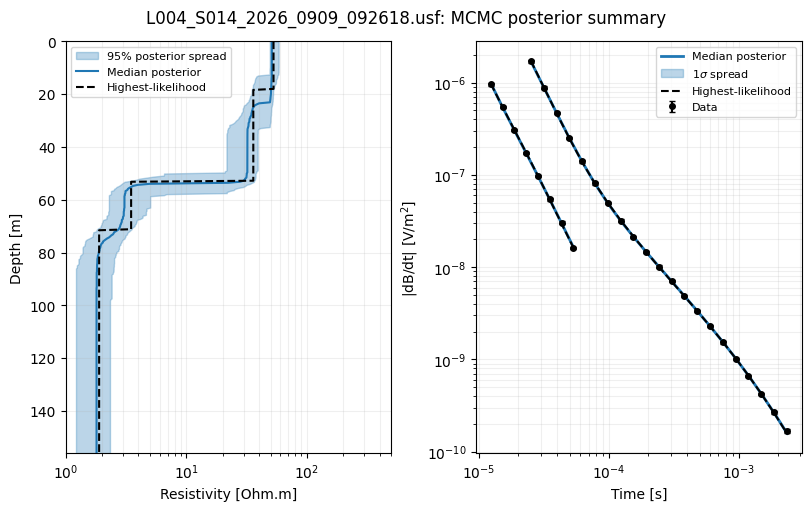

In [58]:
def sample_walkers(n_draws, samples, rng):
    """Forward-model n_draws random posterior samples and summarise as a median +/- spread, per gate."""
    draw = rng.integers(0, len(samples), size=n_draws)
    predictions = np.array([model(samples[i]) for i in draw])
    return np.median(predictions, axis=0), np.std(predictions, axis=0)


def rho_profile(theta, depth_grid):
    """Turn a (log_rho, thickness) theta into a resistivity value at each depth in depth_grid."""
    log_rho, thickness = theta[:N_LAYERS], theta[N_LAYERS:]
    layer_top = np.r_[0.0, np.cumsum(thickness)]
    layer_index = np.searchsorted(layer_top, depth_grid, side='right') - 1
    return 10.0 ** log_rho[np.clip(layer_index, 0, N_LAYERS - 1)]


best_fit_prediction = model(theta_max)
median_prediction, spread = sample_walkers(200, flat_samples, np.random.default_rng(0))

zmax = 1.3 * (N_LAYERS - 1) * THICKNESS_RANGE[1]
depth_grid = np.linspace(0.0, zmax, 400)
draw = np.random.default_rng(1).integers(0, len(flat_samples), size=200)
rho_draws = np.array([rho_profile(flat_samples[i], depth_grid) for i in draw])
rho_lo, rho_med, rho_hi = np.percentile(rho_draws, [2.5, 50, 97.5], axis=0)
rho_best = rho_profile(theta_max, depth_grid)

fig, axes = plt.subplots(1, 2, figsize=(8, 5), layout='constrained')
axes[0].fill_betweenx(depth_grid, rho_lo, rho_hi, color='C0', alpha=0.3, label='95% posterior spread')
axes[0].plot(rho_med, depth_grid, 'C0', lw=1.5, label='Median posterior')
axes[0].plot(rho_best, depth_grid, 'k--', lw=1.5, label='Highest-likelihood')
axes[0].set(xscale='log', xlim=RHO_RANGE, ylim=(zmax, 0),
           xlabel='Resistivity [Ohm.m]', ylabel='Depth [m]')
axes[0].legend(fontsize=8)
axes[0].grid(True, which='both', alpha=0.2)

for moment_index, moment in enumerate(MOMENTS):
    valid = valid_gates[moment]
    times = observed_systems[moment]['times'][valid]
    gate_slice = moment_slices[moment]
    label_observed = 'Data' if moment_index == 0 else '_nolegend_'
    label_median = 'Median posterior' if moment_index == 0 else '_nolegend_'
    label_spread = r'$1\sigma$ spread' if moment_index == 0 else '_nolegend_'
    label_best = 'Highest-likelihood' if moment_index == 0 else '_nolegend_'
    axes[1].errorbar(times, obs[gate_slice], yerr=sig[gate_slice], fmt='ko', ms=4,
                     capsize=2, label=label_observed, zorder=5)
    axes[1].loglog(times, np.abs(median_prediction[gate_slice]), 'C0-', lw=2,
                   label=label_median)
    axes[1].fill_between(times,
                         np.abs(median_prediction[gate_slice]) - spread[gate_slice],
                         np.abs(median_prediction[gate_slice]) + spread[gate_slice],
                         color='C0', alpha=0.3, label=label_spread)
    axes[1].loglog(times, np.abs(best_fit_prediction[gate_slice]), 'k--', lw=1.5,
                   label=label_best)
axes[1].set(xlabel='Time [s]', ylabel='|dB/dt| [V/m$^2$]')
axes[1].grid(True, which='both', alpha=0.2)
axes[1].legend(fontsize=8)
fig.suptitle(f'{selected_usf.name}: MCMC posterior summary')
plt.show()

In [ ]:
# lnlike = -0.5 * chi_squared and RMS = sqrt(chi_squared / n_gates), so RMS = sqrt(-2 * lnprob / n_gates)
# (the prior contributes 0 inside bounds, so lnprob == lnlike for every retained sample here).
posterior_rms = np.sqrt(-2.0 * flat_lnprob / obs.size)
best_ensemble_rms = rms_matrix[best_model_index, -1]
print(f'Ensemble search (independent-control resistivity, {N_MODELS} random models): '
      f'best combined RMS = {best_ensemble_rms:.3f}')
print(f'MCMC ({N_CHAINS} chains x {N_STEPS} steps): '
      f'best combined RMS = {posterior_rms.min():.3f}, '
      f'median post-burn-in RMS = {np.median(posterior_rms):.3f}')
print('\nThe MCMC explores many more independent-layer-resistivity models than the '
      f'{N_MODELS}-model ensemble, at a similar per-model cost - the trade-off is '
      'the need to check chain convergence (R-hat above) rather than simply '      
      'ranking a fixed batch of models.')

Ensemble search (independent-control resistivity, 10000 random models): best combined RMS = 1.289
MCMC (6 chains x 12500 steps): best combined RMS = 0.404, median post-burn-in RMS = 0.756

The MCMC explores many more independent-layer-resistivity models than the 10000-model ensemble, at a similar per-model cost - the trade-off is the need to check chain convergence (R-hat above) rather than simply ranking a fixed batch of models.
